In [5]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df = pd.read_csv('/content/drive/MyDrive/training.1600000.processed.noemoticon.csv', encoding='latin-1', names=columns)
# Use only sentiment and text
df = df[['sentiment', 'text']]

# Convert sentiment to binary (0: Negative, 1: Positive)
df['sentiment'] = df['sentiment'].replace({4: 1})

# Optional: view basic info
print(df.head())
print(df['sentiment'].value_counts())


Mounted at /content/drive
   sentiment                                               text
0          0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1          0  is upset that he can't update his Facebook by ...
2          0  @Kenichan I dived many times for the ball. Man...
3          0    my whole body feels itchy and like its on fire 
4          0  @nationwideclass no, it's not behaving at all....
sentiment
0    800000
1    800000
Name: count, dtype: int64


In [6]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)     # remove mentions & hashtags
    text = re.sub(r"[^a-zA-Z\s]", "", text)   # keep only letters
    text = re.sub(r"\s+", " ", text)

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)


[nltk_data] Downloading package wordnet to /root/nltk_data...


In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)     # remove mentions & hashtags
    text = re.sub(r"[^a-zA-Z\s]", "", text)   # keep only letters
    text = re.sub(r"\s+", " ", text)

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000)
X = tfidf.fit_transform(df['cleaned_text'])
y = df['sentiment']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.77764375
              precision    recall  f1-score   support

           0       0.79      0.76      0.77    159494
           1       0.77      0.80      0.78    160506

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



In [3]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 117.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


In [10]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 🔹 Load and preprocess dataset
df = df[['sentiment', 'text']]
df['sentiment'] = df['sentiment'].replace({4: 1})

# 🔹 Clean the text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df['text'].apply(clean_text)

# 🔹 Limit dataset for faster training (optional)
df = df.sample(150000, random_state=42)

# 🔹 Tokenization and Padding
max_vocab = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])

X = tokenizer.texts_to_sequences(df['cleaned_text'])
X = pad_sequences(X, maxlen=max_len, padding='post')

y = df['sentiment'].values

# 🔹 Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 Build the LSTM model
model = Sequential([
    Embedding(input_dim=max_vocab, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# 🔹 Train the model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=5, batch_size=256)

# 🔹 Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {accuracy:.4f}")

# 🔹 Classification report
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 307s 810ms/step - accuracy: 0.6722 - loss: 0.5843 - val_accuracy: 0.7670 - val_loss: 0.4862
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 292s 780ms/step - accuracy: 0.7927 - loss: 0.4459 - val_accuracy: 0.7676 - val_loss: 0.4833
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 292s 779ms/step - accuracy: 0.8098 - loss: 0.4089 - val_accuracy: 0.7655 - val_loss: 0.4955
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 292s 778ms/step - accuracy: 0.8238 - loss: 0.3763 - val_accuracy: 0.7633 - val_loss: 0.5355
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 292s 779ms/step - accuracy: 0.8414 - loss: 0.3401 - val_accuracy: 0.7567 - val_loss: 0.6042
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.7552 - loss: 0.6092

✅ Test Accuracy: 0.7571
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step
              precision    recall  f1-score   support

           0       0.75      0.77      0.76     14968
           1       0.77      0.74      0.75     15032

    accuracy                        

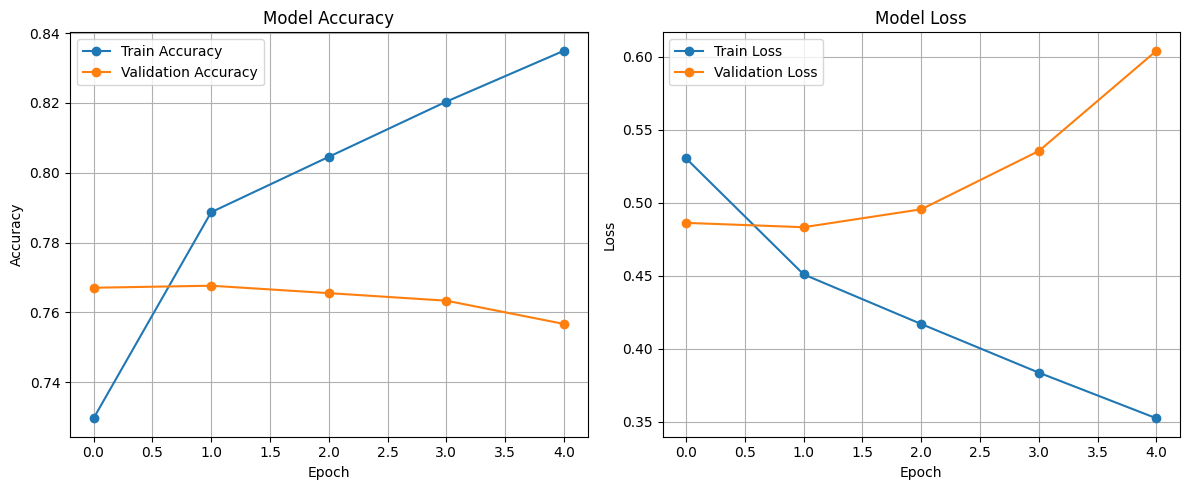

In [12]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [13]:
# Calculate counts and percentages
label_counts = df['sentiment'].value_counts()
label_percentages = df['sentiment'].value_counts(normalize=True) * 100

# Combine into a DataFrame
label_distribution = pd.DataFrame({
    'Label': label_counts.index,
    'Count': label_counts.values,
    'Percentage': label_percentages.values.round(2)
})

# Sort by Label (Optional)
label_distribution = label_distribution.sort_values('Label').reset_index(drop=True)

# Display the table
print("\n📊 Dataset Label Distribution Table:")
print(label_distribution.to_string(index=False))



📊 Dataset Label Distribution Table:
 Label  Count  Percentage
     0  74807       49.87
     1  75193       50.13


In [14]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post')
    prediction = model.predict(padded)[0][0]

    sentiment = "Positive" if prediction > 0.5 else "Negative"
    confidence = round(prediction if sentiment == "Positive" else 1 - prediction, 4)

    print(f"\n📝 Tweet: {text}")
    print(f"🧼 Cleaned: {cleaned}")
    print(f"📊 Prediction: {prediction:.4f}")
    print(f"✅ Sentiment: {sentiment} (Confidence: {confidence * 100:.2f}%)")


In [15]:
# Save model
model.save("lstm_sentiment_model.h5")

# Save tokenizer
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


# **APP.py**

In [ ]:
import streamlit as st
import tensorflow as tf
import numpy as np
import pickle
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.sequence import pad_sequences
from googletrans import Translator
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# Download stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load tokenizer and model safely
try:
    with open("tokenizer.pkl", "rb") as handle:
        tokenizer = pickle.load(handle)
    model = tf.keras.models.load_model("lstm_sentiment_model.h5")
except Exception as e:
    st.error("❌ Failed to load model or tokenizer.")
    st.stop()

MAX_LEN = 100
translator = Translator()

# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words), words

def get_importance_by_length(words, top_n=5):
    word_scores = [(word, len(word)) for word in words]
    return sorted(word_scores, key=lambda x: x[1], reverse=True)[:top_n]


# Streamlit UI
st.set_page_config(page_title="Multilingual LSTM Sentiment Analyzer", layout="centered")
st.title("🌐 Multilingual LSTM Sentiment Analysis App")
st.write("Enter text in **any language**, and we'll analyze its **sentiment**!")

# Text input
user_input = st.text_area("✏️ Enter your sentence:", height=150)

# Analyze
if st.button("🔍 Analyze"):
    if user_input.strip() == "":
        st.warning("⚠️ Please enter some text first.")
    else:
        try:
            # Translate to English
            translated = translator.translate(user_input, dest="en")
            translated_text = translated.text

            # Clean text
            cleaned_text, word_list = clean_text(translated_text)

            # Sequence and prediction
            seq = tokenizer.texts_to_sequences([cleaned_text])
            padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
            prediction = model.predict(padded)[0][0]
            label = "Positive 😊" if prediction >= 0.5 else "Negative 😞"

            st.subheader("🧾 Result")
            st.write(f"**Original Input:** {user_input}")
            st.write(f"**Translated (EN):** {translated_text}")
            st.write(f"**Sentiment:** {label}")
            st.write(f"**Confidence:** {prediction:.2%}")

            # Word importance chart using TF-IDF
            top_words = get_importance_by_length(word_list)


            if top_words:
                words, scores = zip(*top_words)

                fig, ax = plt.subplots()
                ax.bar(words, scores, color='skyblue')
                ax.set_title("Top Important Words (TF-IDF)")
                ax.set_xlabel("Words")
                ax.set_ylabel("Importance Score")
                ax.set_ylim(0, max(scores) + 0.1)
                ax.grid(axis='y', linestyle='--', alpha=0.7)

                st.pyplot(fig)
            else:
                st.info("No important words found (input might be too short or all stopwords).")

        except Exception as e:
            st.error(f"❌ Error: {str(e)}")
